In [1]:
import csv
from datetime import datetime
import requests
from bs4 import BeautifulSoup

def get_url(position, location):
    """Generate a url from position and location"""
    template = 'https://fr.indeed.com/jobs?q={}&l={}'
    url = template.format(position, location)
    return url

# FOR EACH JOB TITLE OUT OF 15, WE COLLECT JOB INFORMATION IN PIECES
def get_record(card):
    """Extract job data from a single record"""
    atag = card.h2.find_all('span')
    count = int (len(atag))
    if count == 2:
        job_title = atag[1].get('title')
    else:
        job_title = atag[0].get('title')

    job_url = 'https://fr.indeed.com' + card.h2.a.get('href')
    # jurl = card.find_all('span', attrs={'class': 'mat'})
    # job_href = [i.find("a")["href"] for i in jurl]
    # for job_href in job_href:
    #     job_url = 'https://fr.indeed.com' + job_href

    company = card.find('span', 'companyName').text.strip()
    location = card.find('div', 'companyLocation').text
    summary = card.find('div', 'job-snippet').text
    posted_date = card.find('span', 'date').text
    cur_date = datetime.today().strftime('%Y-%m-%d')

    try:
        salary = card.find('div', 'attribute_snippet').text
    except AttributeError:
        salary = ''

    record = (job_title, company, location, posted_date, cur_date, summary, salary, job_url)
    return record

def main(position, location):
    """Run the main program routine"""
    records = []
    url = get_url(position, location)
    
    while True:
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        # cards = soup.find_all('div', 'jobsearch-SerpJobCard')
        cards = soup.find_all('div', 'job_seen_beacon')

        for card in cards:
          #call get_record to collect requested information about each job from CARD
          record = get_record(card)
          records.append(record)
        try:
            url = 'https://fr.indeed.com' + soup.find('a', {'aria-label': 'Suivant'}).get('href')
        except AttributeError:
            break
        
    # SAVE THE JOB DATA
    with open('internship.csv', 'w', newline = '', encoding = 'utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['job_title', 'company', 'location', 'posted_date', 'cur_date', 'summary', 'salary', 'job_url'])
        for i in records:
          writer.writerow(i)
          print(i)


In [2]:
# RUN THE MAIN PROGRAM
main('internship', 'paris')

In [9]:
ls -l

 Volume in drive C has no label.
 Volume Serial Number is 3EA1-F07B

 Directory of C:\Users\A.S.A



File Not Found


In [3]:
from pandas import DataFrame
import pandas as pd
df_intern = pd.read_csv('/content/internship.csv')
df_intern.tail()

FileNotFoundError: [Errno 2] No such file or directory: '/content/internship.csv'

In [4]:
# Clean summary text
df_intern['summary'] = df_intern['summary'].str[0:-1]
df_intern.tail()

NameError: name 'df_intern' is not defined

In [ ]:
# Clean PostDate
df_intern['posted_date'] = df_intern['posted_date'].str.replace('jours', 'days ago', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('jour', 'day ago', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('Postedil y a', 'Posted:', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('EmployerDernière activité', 'Posted:', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace(': il y a', ' ', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('PostedPublié à l\'instant', 'Posted: 0 day agos', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('PostedAuday agod\'hui', 'Posted: 1 days agos', regex=True)
df_intern['posted_date'] = df_intern['posted_date'].str.replace('Employeril y a 30 days ago', 'Posted: 30 days agos', regex=True)
df_intern['summary'] = df_intern['summary'].str.replace('è', 'e', regex=True)
df_intern['summary'] = df_intern['summary'].str.replace('’', '\'', regex=True)
df_intern['summary'] = df_intern['summary'].str.replace('…', '...', regex=True)
df_intern['summary'] = df_intern['summary'].str.replace('é', 'e', regex=True)
df_intern['location'] = df_intern['location'].str.replace('é', 'e', regex=True)
df_intern['location'] = df_intern['location'].str.replace('à', 'a', regex=True)
df_intern['title'] = df_intern['title'].str.replace('è', 'e', regex=True)
df_intern['title'] = df_intern['title'].str.replace('é', 'e', regex=True)
df_intern.tail(10)


,job_title,company,location,posted_date,cur_date,summary,salary,job_url
8,Internship - CSR coordinator (M/W),CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,"\nReporting to the Central Director, your main...",NaN,https://fr.indeed.com/rc/clk?jk=4916e53147a062...
9,Stage - Ingénieur.e d'exploitation et performa...,SUEZ,Aix-en-Provence (13),Posted: 30+ days ago,2022-06-18,\nSUEZ Recyclage & Valorisation des dechets pr...,NaN,https://fr.indeed.com/rc/clk?jk=cb1134115c81f0...
10,Alternance - Financial Controller (M/F),CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,\nAs a member of the CMA CGM Terminals Departm...,NaN,https://fr.indeed.com/rc/clk?jk=94d450d443d2fc...
11,Fixed term contract Apprenticeship - Shipping ...,CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,\nYou recently graduated from a Master 2 degre...,NaN,https://fr.indeed.com/rc/clk?jk=773a20150142dd...
12,Inside sales (M/F),CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,\nYou will join the Key Account Marketing & Sa...,NaN,https://fr.indeed.com/rc/clk?jk=62e50c3205ea5f...
13,Apprenticeship - Press Relations (M/F),CMACGM,Marseille (13),Posted: 25 days ago,2022-06-18,\nIntegrated in the press division of the Comm...,NaN,https://fr.indeed.com/rc/clk?jk=1fd696ce1d1d2a...
14,Operations Internship- France,Voi Technology,Marseille (13),Posted: 30+ days ago,2022-06-18,\nYou may be in your last year of a master's d...,NaN,https://fr.indeed.com/rc/clk?jk=6dac4d7c37d6f0...
15,Postdoctoral position in organic chemistry,Institut de Chimie Radicalaire,13014 Marseille 14e,Posted: 4 days ago,2022-06-18,\nPHOTO project explores new polymerization st...,De 2 400 € à 2 600 € par mois,https://fr.indeed.com/company/Institut-de-Chim...
16,Operations Internship - Marseille,Indie Campers,Marignane (13),Posted: 30+ days ago,2022-06-18,\nMinimum of 3 months and up to 12 months inte...,Stage,https://fr.indeed.com/rc/clk?jk=c404e12285bb27...
17,Contracts Intern,Presto Engineering,13590 Meyreuil,Posted: 4 days ago,2022-06-18,"\nAs a Contracts Intern, you will be assisting...",Stage,https://fr.indeed.com/company/PRESTO-ENGINEERI...


**ANNOUNCEMENTS FOR APPRENTICESHIP**

In [ ]:
import csv
from datetime import datetime
import requests
from bs4 import BeautifulSoup

def get_url(position, location):
    """Generate a url from position and location"""
    template = 'https://fr.indeed.com/jobs?q={}&l={}'
    url = template.format(position, location)
    return url

# FOR EACH JOB TITLE OUT OF 15, WE COLLECT JOB INFORMATION IN PIECES
def get_record(card):
    """Extract job data from a single record"""
    atag = card.h2.find_all('span')
    count = int (len(atag))
    if count == 2:
        job_title = atag[1].get('title')
    else:
        job_title = atag[0].get('title')

    job_url = 'https://fr.indeed.com' + card.h2.a.get('href')
    # jurl = card.find_all('span', attrs={'class': 'mat'})
    # job_href = [i.find("a")["href"] for i in jurl]
    # for job_href in job_href:
    #     job_url = 'https://fr.indeed.com' + job_href

    company = card.find('span', 'companyName').text.strip()
    location = card.find('div', 'companyLocation').text
    summary = card.find('div', 'job-snippet').text
    posted_date = card.find('span', 'date').text
    cur_date = datetime.today().strftime('%Y-%m-%d')

    try:
        salary = card.find('div', 'attribute_snippet').text
    except AttributeError:
        salary = ''

    record = (job_title, company, location, posted_date, cur_date, summary, salary, job_url)
    return record

def main1(position, location):
    """Run the main program routine"""
    records = []
    url = get_url(position, location)
    
    while True:
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        # cards = soup.find_all('div', 'jobsearch-SerpJobCard')
        cards = soup.find_all('div', 'job_seen_beacon')

        for card in cards:
          #call get_record to collect requested information about each job from CARD
          record = get_record(card)
          records.append(record)
        try:
            url = 'https://fr.indeed.com' + soup.find('a', {'aria-label': 'Suivant'}).get('href')
        except AttributeError:
            break
        
    # SAVE THE JOB DATA
    with open('apprenticeship.csv', 'w', newline = '', encoding = 'utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['job_title', 'company', 'location', 'posted_date', 'cur_date', 'summary', 'salary', 'job_url'])
        for i in records:
          writer.writerow(i)
          print(i)


In [ ]:
# RUN THE MAIN PROGRAM
main1('apprenticeship', 'marseille')

('Apprenticeship - Puchasing Assistant (M/F)', 'CMAShips', 'Marseille (13)', 'Postedil y a 1 jour', '2022-06-18', '\nLed by Rodolphe Saadé, the CMA CGM Group, a global leader in shipping and logistics, serves more than 420 ports around the world on five continents.\n', '', 'https://fr.indeed.com/rc/clk?jk=f68807295e814534&fccid=ca85891d153458b9&vjs=3')
('Apprenticeship in Back Office Management', 'HSBC', 'Marseille (13)', 'Postedil y a 30+ jours', '2022-06-18', "\nPlease note this apprenticeship advertisement is only available in French.\nTo view this apprenticeship offer, change the language of the page to 'Français -…\n", '', 'https://fr.indeed.com/rc/clk?jk=de9e8fa54ec3e08b&fccid=04c9b139c84ea1b5&vjs=3')
('Apprenticeship in Wealth Management', 'HSBC', 'Marseille (13)', 'Postedil y a 30+ jours', '2022-06-18', "\nPlease note this apprenticeship advertisement is only available in French.\nTo view this apprenticeship offer, change the language of the page to 'Français -…\n", '', 'https:

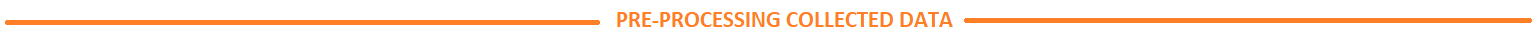

In [ ]:
from pandas import DataFrame
import pandas as pd
df_appr = pd.read_csv('/content/apprenticeship.csv')
df_appr.tail()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
75,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Postedil y a 30+ jours,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
76,Apprenti(e) ingénieur certification & qualific...,Airbus,13700 Marignane,Postedil y a 30+ jours,2022-06-18,\nVous rejoindrez une équipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
77,Apprenti déclarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Postedil y a 30+ jours,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
78,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Postedil y a 15 jours,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
79,Operations Apprenticeship France,Voi Technology,Marseille (13),Postedil y a 30+ jours,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


In [ ]:
# Clean summary text
df_appr['summary'] = df_appr['summary'].str[0:-1]
df_appr.tail()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
75,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Postedil y a 30+ jours,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
76,Apprenti(e) ingénieur certification & qualific...,Airbus,13700 Marignane,Postedil y a 30+ jours,2022-06-18,\nVous rejoindrez une équipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
77,Apprenti déclarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Postedil y a 30+ jours,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
78,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Postedil y a 15 jours,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
79,Operations Apprenticeship France,Voi Technology,Marseille (13),Postedil y a 30+ jours,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


In [ ]:
# Clean PostDate
df_appr['posted_date'] = df_appr['posted_date'].str.replace('jours', 'days ago', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('jour', 'day ago', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('Postedil y a', 'Posted:', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('EmployerDernière activité', 'Posted:', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace(': il y a', ' ', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('PostedPublié à l\'instant', 'Posted: 0 day agos', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('PostedAuday agod\'hui', 'Posted: 1 days agos', regex=True)
df_appr['posted_date'] = df_appr['posted_date'].str.replace('Employeril y a 30 days ago', 'Posted: 30 days agos', regex=True)
df_appr['summary'] = df_appr['summary'].str.replace('’', '\'', regex=True)
df_appr['summary'] = df_appr['summary'].str.replace('…', '...', regex=True)
df_appr['summary'] = df_appr['summary'].str.replace('é', 'e', regex=True)
df_appr['summary'] = df_appr['summary'].str.replace('à', 'a', regex=True)
df_appr['summary'] = df_appr['summary'].str.replace('è', 'e', regex=True)
df_appr['job_title'] = df_appr['job_title'].str.replace('è', 'e', regex=True)
df_appr['location'] = df_appr['location'].str.replace('é', 'e', regex=True)
df_appr['job_title'] = df_appr['job_title'].str.replace('é', 'e', regex=True)
df_appr['location'] = df_appr['location'].str.replace('à', 'a', regex=True)
df_appr['job_title'] = df_appr['job_title'].str.replace('à', 'a', regex=True)
df_appr.tail()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
75,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
76,Apprenti(e) ingenieur certification & qualific...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nVous rejoindrez une equipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
77,Apprenti declarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Posted: 30+ days ago,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
78,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Posted: 15 days ago,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
79,Operations Apprenticeship France,Voi Technology,Marseille (13),Posted: 30+ days ago,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


**JOIN BOTH DATA FILES**

In [ ]:
df_all = df_intern.append(df_appr, ignore_index = True)

df_all_uniq = df_all.drop_duplicates(subset=['job_title', 'company'])
df_all_uniq.tail()


,job_title,company,location,posted_date,cur_date,summary,salary,job_url
93,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
94,Apprenti(e) ingenieur certification & qualific...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nVous rejoindrez une equipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
95,Apprenti declarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Posted: 30+ days ago,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
96,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Posted: 15 days ago,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
97,Operations Apprenticeship France,Voi Technology,Marseille (13),Posted: 30+ days ago,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


In [ ]:
df_all_uniq.head()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
0,Internship - Performance Management Improvemen...,CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,"\nDuring your internship, you will acquire rea...",NaN,https://fr.indeed.com/rc/clk?jk=e3cd451c91f019...
1,Student Ambassador,EDUopinions,Marseille (13),Recrutement régulier,2022-06-18,\nYour role would be to get reviews online fro...,NaN,https://fr.indeed.com/company/EDUopinions/jobs...
2,Apprenticeship - Puchasing Assistant (M/F),CMAShips,Marseille (13),Posted: 1 day ago,2022-06-18,\nCurrently in a Master's degree specializing ...,NaN,https://fr.indeed.com/rc/clk?jk=f68807295e8145...
3,Internship - Performance Management Improvemen...,CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,\nAu sein du Departement Operations & Group As...,NaN,https://fr.indeed.com/rc/clk?jk=9977145e422aab...
4,Logistic Recovery Container Officer (M/F),CMACGM,Marseille (13),Posted: 9 days ago,2022-06-18,\nPost graduate degree in Engineering or Busin...,NaN,https://fr.indeed.com/rc/clk?jk=46f5593780b93f...


**EXPORT DATA AS CSV**

In [ ]:
df_all_uniq.to_csv('/content/clean_data.csv', index=False)

In [ ]:
df_all_uniq.tail()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
93,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
94,Apprenti(e) ingenieur certification & qualific...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nVous rejoindrez une equipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
95,Apprenti declarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Posted: 30+ days ago,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
96,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Posted: 15 days ago,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
97,Operations Apprenticeship France,Voi Technology,Marseille (13),Posted: 30+ days ago,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


In [ ]:
df_sql = pd.read_csv('/content/clean_data.csv')
# df_sql = df_all_uniq
df_sql.tail()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url
83,Apprenti en Communication - Gestion des Ressou...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nEtablir et soutenir un plan de communication...,NaN,https://fr.indeed.com/rc/clk?jk=04633dd5a377ca...
84,Apprenti(e) ingenieur certification & qualific...,Airbus,13700 Marignane,Posted: 30+ days ago,2022-06-18,\nVous rejoindrez une equipe de 5 personnes au...,NaN,https://fr.indeed.com/rc/clk?jk=cb14429ca97350...
85,Apprenti declarant en douane / Customs declara...,Clasquin,13127 Vitrolles,Posted: 30+ days ago,2022-06-18,\nMaitriser les systèmes informatiques douane ...,NaN,https://fr.indeed.com/rc/clk?jk=8eb17d30619961...
86,Apprenticeship Marketing Officer,AVIV Group,13290 Aix-en-Provence,Posted: 15 days ago,2022-06-18,\nNous encourageons vivement les personnes iss...,NaN,https://fr.indeed.com/rc/clk?jk=7bbf56974e43c2...
87,Operations Apprenticeship France,Voi Technology,Marseille (13),Posted: 30+ days ago,2022-06-18,\nWork closely with the Operations team to par...,NaN,https://fr.indeed.com/rc/clk?jk=e77e1a920a7920...


In [ ]:
### EXTRACT POSTED DATE NUMBER AND ADD AS A NEW COLUMN

df_sql['pdate'] = [df_sql.posted_date.str.split(" ")[index][1]
for index in range(0, len(df_sql))]
df_sql.head()

,job_title,company,location,posted_date,cur_date,summary,salary,job_url,pdate
0,Internship - Performance Management Improvemen...,CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,"\nDuring your internship, you will acquire rea...",NaN,https://fr.indeed.com/rc/clk?jk=e3cd451c91f019...,30+
1,Student Ambassador,EDUopinions,Marseille (13),Recrutement régulier,2022-06-18,\nYour role would be to get reviews online fro...,NaN,https://fr.indeed.com/company/EDUopinions/jobs...,régulier
2,Apprenticeship - Puchasing Assistant (M/F),CMAShips,Marseille (13),Posted: 1 day ago,2022-06-18,\nCurrently in a Master's degree specializing ...,NaN,https://fr.indeed.com/rc/clk?jk=f68807295e8145...,1
3,Internship - Performance Management Improvemen...,CMACGM,Marseille (13),Posted: 30+ days ago,2022-06-18,\nAu sein du Departement Operations & Group As...,NaN,https://fr.indeed.com/rc/clk?jk=9977145e422aab...,30+
4,Logistic Recovery Container Officer (M/F),CMACGM,Marseille (13),Posted: 9 days ago,2022-06-18,\nPost graduate degree in Engineering or Busin...,NaN,https://fr.indeed.com/rc/clk?jk=46f5593780b93f...,9


In [ ]:
### INCASE WE WANT TO CONVERT EMPTY/NAN CELLS TO NULL
# import numpy as np
# df_all_uniq['salary'] = df_all_uniq['salary'].replace(np.nan, pymysql.NULL)
# df_all_uniq.head(3)

df_sql[df_sql['job_title'] == 'ALT 2022 Apprentice Sales and Marketing']

,job_title,company,location,posted_date,cur_date,summary,salary,job_url,pdate


In [ ]:
!pip install mysql.connector
!pip install pymysql

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


### IN CASE WE WANT TO QUERY/SELECT DATA FROM DATABASE

In [ ]:
# import os
# import pymysql
# import mysql.connector
# import pandas as pd

# conn = mysql.connector.connect(
#     host='',
#     port=int(3306),
#     user='',
#     passwd="",
#     db="",
#     charset='utf8mb4'
#     )

# df = pd.read_sql_query("SELECT * from annos", conn)
# df.tail(10)

### IN CASE WE WANT TO UPDATE A SINGLE CELL IN DATABASE

In [ ]:
# mycursor = conn.cursor()
# # sal =/ 66

# sql = """UPDATE annos SET salary = 44556"""
# # tuple1 = (112233)
# mycursor.execute(sql)
# conn.commit()

# for x in mycursor:
#   print(len(x))

**CONNECT TO THE DATABASE AND INSERT CLEAN DATA INTO DATABASE**

In [ ]:
from pandas.io import sql
from sqlalchemy import create_engine

engine = create_engine("mysql+pymysql://{user}:{pw}@IP/{db}"
                       .format(user="",
                               pw="",
                               db="",
                               charset='utf8'))
df_sql.to_sql(con=engine, name='annos', if_exists='append', index=False)

**REMOVE DUPLICATE RECORDS FROM DATABASE**

In [ ]:
import os
import pymysql
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='',
    port=int(3306),
    user='',
    passwd="",
    db="",
    charset='utf8'
    # mysql_set_charset="utf8"
)
import mysql.connector
mycursor = conn.cursor()

sql = """DELETE t1 FROM annos t1 INNER JOIN annos t2 WHERE t1.index < t2.index AND t1.job_title = t2.job_title AND t1.company = t2.company"""

mycursor.execute(sql)
conn.commit()

df_sql_uniq = pd.read_sql_query("SELECT * from annos", conn)
df_sql_uniq.tail()
df_sql_uniq.count()

index          2359
job_title      2359
company        2359
location       2359
posted_date    2359
cur_date       2359
summary        2359
salary         2359
job_url        2359
pdate          2359
dtype: int64

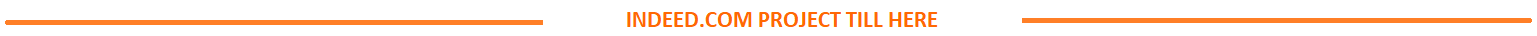